# Plot 2d histogram relation of postprocess data

In [1]:
import h5py
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import struct
from scipy.optimize import curve_fit
import time
import illustris_python as il
import astropy

In [2]:
import sys
sys.path.append('/home/tnguser/TNGCluster')

from astro_utils.function_coord import *
from astro_utils.function_plot import *
from astro_utils.spherical_coord import *
from astro_utils.utils_astro import *
from astro_utils.IllustrisTNG_functions.Get_Particles_snap import *
from astro_utils.IllustrisTNG_functions.function_illustris import *

from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units  as u
from scipy.stats import binned_statistic
from collections import OrderedDict

In [3]:

# Take 10% of particles for speed
frac = 0.1

def sample_arrays(x, y, z, frac=0.1):
    n = len(x)
    n_sample = max(1, int(frac * n))
    idx = np.random.choice(np.arange(n), n_sample, replace=False)
    return x[idx], y[idx], z[idx]

def posvel_sample_arrays(pos, vel, frac=0.1):

    n = len(pos)
    n_sample = max(1, int(frac * n))
    idx = np.random.choice(n, n_sample, replace=False)
    return pos[idx], vel[idx]

# Histogram of $\rho$ vs T

In [4]:
basePath_tngcluster = '/home/tnguser/sims.TNG/TNG-Cluster/output'
basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'
basePath_tng100 = '/home/tnguser/sims.TNG/TNG100-1/output'
basePath_tng300 = '/home/tnguser/sims.TNG/TNG300-1/output'

base_out = '/home/tnguser/TNGCluster/'

G=43007.1/1.e10     # Constante de Newton en unidades de masas solares
#mass_DM_particle = 3.07367708626464e-05 # TNG50
#mass_DM_particle = 5.05574296e-04 # TNG100
mass_DM_particle = 0.00074374 # TNG300 + TNGCluster

##########Track subfind_number_z0 from zmin to zmax.  #############
nz=3
zmin = 0
zmax = 0.5

Processing snapshot 99...


/tmp/ipykernel_4979/2749326480.py:166: RuntimeWarning: divide by zero encountered in log10
  img = np.log10(hist[0].T)


Processing snapshot 81...
Processing snapshot 67...


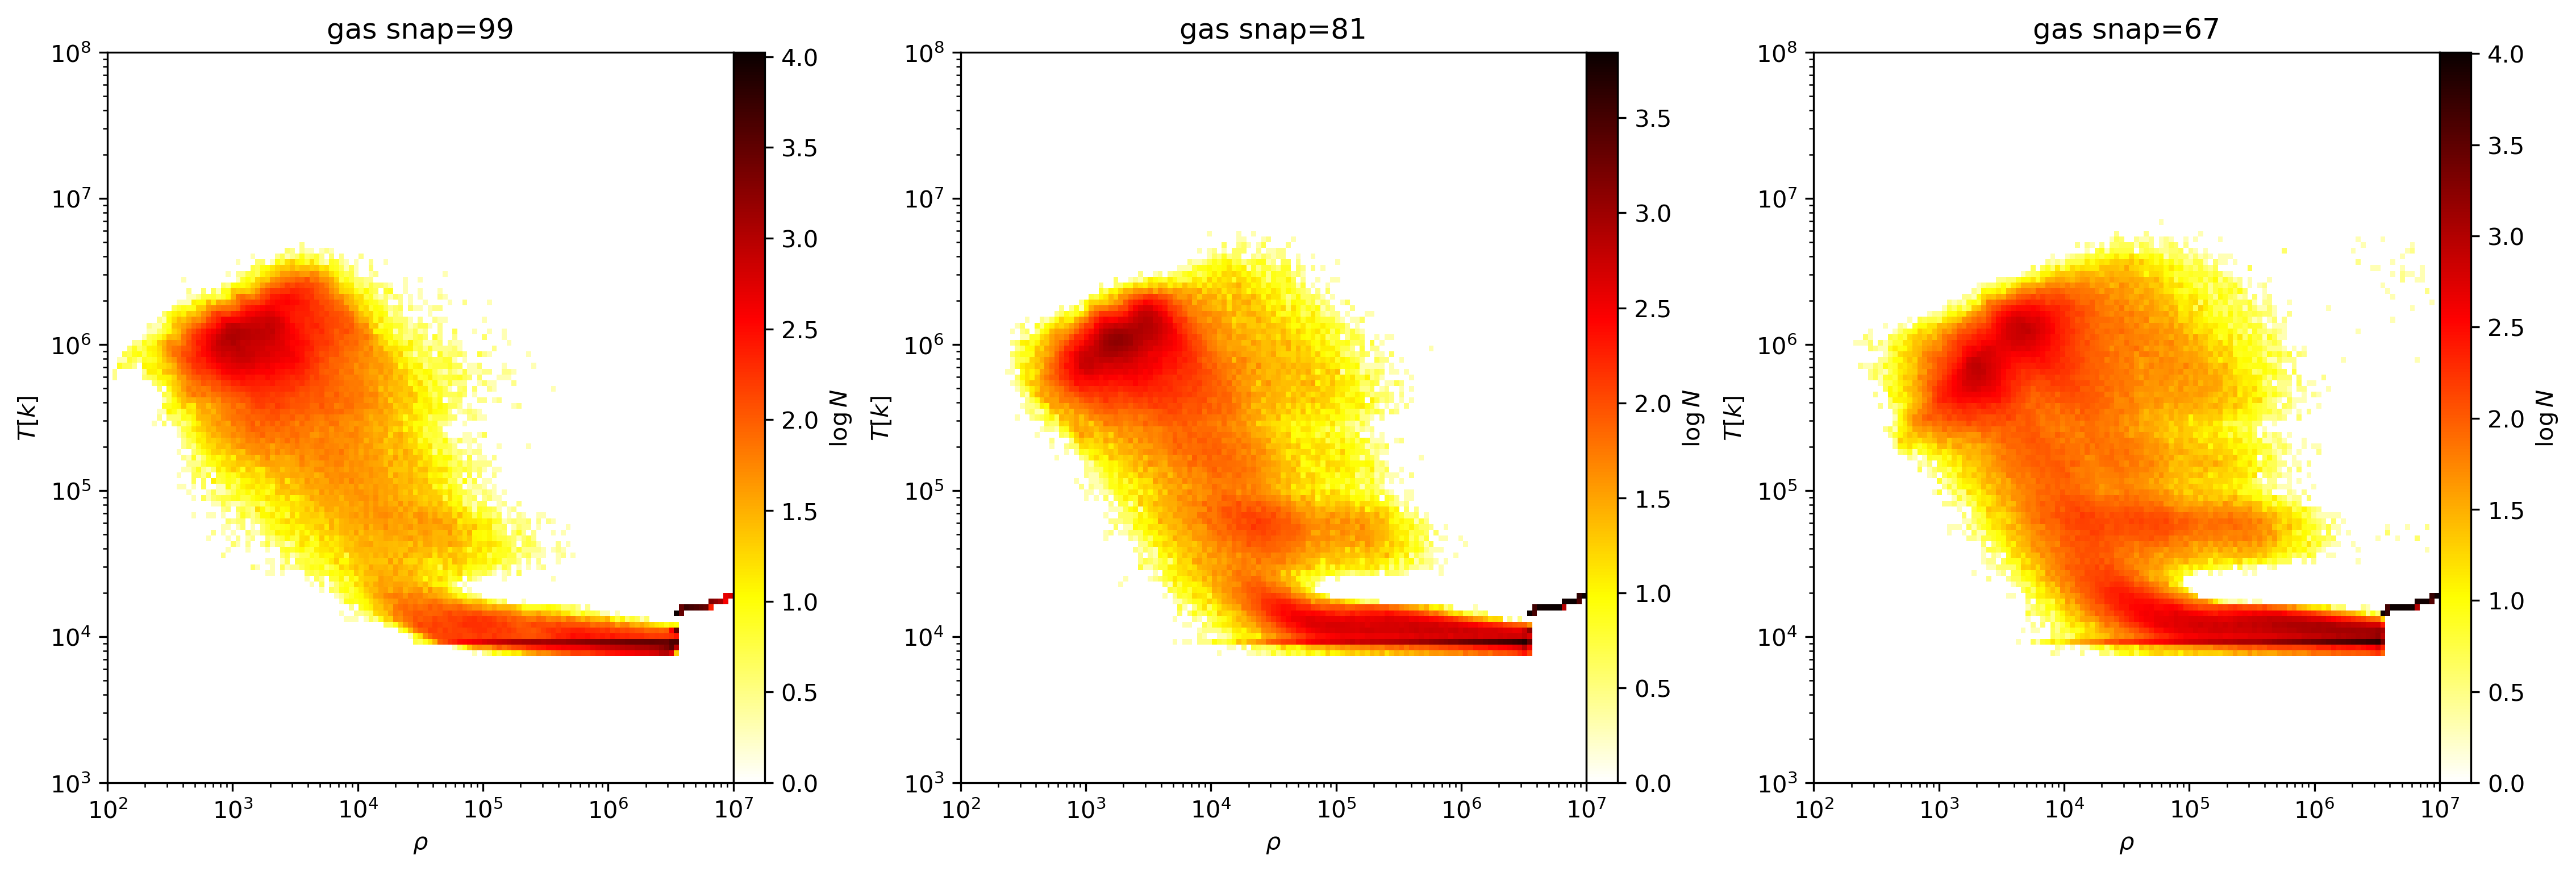

In [28]:
############## Data ##############

snap_number=99 
subfind_number_z0= 517271
box_length= 100
####### List of snap vs z vs aex ########

data = np.load(base_out+"snap_vs_z.npz")
snap_selected = data['snaparr']
z_selected = data['zselected']
aexp_selected = data['aexselected']

######## Track ########

snap_lista= []
z_wanted = np.linspace(zmin,zmax, nz)    
z_wanted = list(z_wanted)

for z in z_wanted:
    idx = find_nearest(z_selected, z)
    snap_lista.append(int(snap_selected[idx]))

snap_lista = list(OrderedDict.fromkeys(snap_lista))
z_wanted = list(np.around(np.array(z_wanted),2))

###########Track ids of subfind_number_z0 for z_wanted ########

fields = ['SubhaloMass','SubfindID','SnapNum']
tree = il.sublink.loadTree(basePath_tng50, 99, subfind_number_z0, fields=fields, onlyMPB=True)
SnapTree = tree['SnapNum']
SubfindIDTree = tree['SubfindID']
mass_msun = tree['SubhaloMass'] * 1e10 / 0.6774

a = SnapTree
b = set(snap_lista)
c =[i for i, item in enumerate(a) if item in b]

subfind_number = SubfindIDTree[c] # The target galaxy from subfind_number_z0
mass_msun = mass_msun[c]


############ FoF and Subfind ###########
fig, axs = plt.subplots(1, 3, constrained_layout=True, dpi=300,figsize=(15,5))

for m, snap_number in enumerate(snap_lista):
    print(f'Processing snapshot {snap_number}...')

    Header = il.groupcat.loadHeader(basePath_tng50, snap_number)
    redsh = Header['Redshift'][()]
    aexp = Header['Time'][()]
    hh = Header['HubbleParam'][()]
    Omega0 = Header['Omega0'][()]
    OmegaLambda = Header['OmegaLambda'][()]
    cosmo = FlatLambdaCDM(H0=hh * 100, Om0=Omega0)
    Hubb = cosmo.H(redsh).to(u.km / u.kpc / u.s).value
    adot = Hubb * aexp
    rho_crit = cosmo.critical_density(redsh).to(u.Msun / u.kpc**3).value

    # --- Group and subhalo data ---
    subhalo = il.groupcat.loadSingle(basePath_tng50, snap_number, subhaloID=subfind_number[m])
    SubhaloPos = np.array(subhalo['SubhaloPos']) / hh
    SubhaloGrNr = subhalo['SubhaloGrNr']
    SubhaloMass = subhalo['SubhaloMass'] * 1e10 / hh

    halo = il.groupcat.loadSingle(basePath_tng50, snap_number, haloID=SubhaloGrNr)
    Group_R_Crit200 = halo['Group_R_Crit200'] * aexp
    Group_M_Crit200 = halo['Group_M_Crit200'] * 1e10 / hh
    GroupPos = halo['GroupPos'] / hh
    GroupVel = halo['GroupVel']

    # --- Physical coordinates and velocities of the group ---
    cmx, cmy, cmz = (GroupPos * aexp)
    vcmx, vcmy, vcmz = (GroupVel * aexp**-1 + GroupPos * adot / hh)
    center = np.array([cmx, cmy, cmz])
    vcenter = np.array([vcmx, vcmy, vcmz])

    ################## Load particle data #################
    dm = snap_phy_subhalo(basePath_tng50, snap_number, subfind_number[m], 1, aexp, adot, hh)
    gas = snap_phy_subhalo(basePath_tng50, snap_number, subfind_number[m], 0, aexp, adot, hh, ['Masses','GFM_Metallicity','InternalEnergy','ElectronAbundance','Density',])
    star = snap_phy_subhalo(basePath_tng50, snap_number, subfind_number[m], 4, aexp, adot, hh, ['Masses', 'Potential'])

    # Dark Matter
    xdm, ydm, zdm = dm['pos'].T
    vxdm, vydm, vzdm = dm['vel'].T
    nDM = len(xdm)
    mDM = np.ones(nDM) * mass_DM_particle * 1e10

    # Stars
    xstar, ystar, zstar = star['pos'].T
    vxstar, vystar, vzstar = star['vel'].T
    ms = star['mass']
    ebin_s = star['pot']

    # Gas
    xgas, ygas, zgas = gas['pos'].T
    vxgas, vygas, vzgas = gas['vel'].T
    mg = gas['mass']
    Z = gas['GFM_Metallicity'] 
    Eint = gas['InternalEnergy'] 
    xe = gas['ElectronAbundance'] 
    Density = gas['Density'] 
    Temp = compute_gas_temperature(Eint,xe)
    

    ######## Recalculate the center of mass ########
    flag_cm = 1
    if flag_cm > 0:
        pos_star = star['pos']
        vel_star = star['vel']
        xcm, ycm, zcm, vxcm, vycm, vzcm = shrinking_sphere(pos_star, vel_star, ms)
    else:
        xcm, ycm, zcm, vxcm, vycm, vzcm = cmx, cmy, cmz, vcmx, vcmy, vcmz

    center = np.array([xcm, ycm, zcm])
    vcenter = np.array([vxcm, vycm, vzcm])

    ################ Relative coordinates #################
    # Stars
    pos_star_rel = star['pos'] - center
    vel_star_rel = star['vel'] - vcenter
    rpristar = np.linalg.norm(pos_star_rel, axis=1)
    order = np.argsort(rpristar)
    rpristar_ord = rpristar[order]
    mstar_ord = ms[order]
    ns = len(mstar_ord)

    # Gas
    pos_gas_rel = gas['pos'] - center
    vel_gas_rel = gas['vel'] - vcenter
    rprigas = np.linalg.norm(pos_gas_rel, axis=1)
    order = np.argsort(rprigas)
    rprigas_ord = rprigas[order]
    mgas_ord = mg[order]
    ng = len(mgas_ord)

    # DM
    pos_dm_rel = dm['pos'] - center
    vel_dm_rel = dm['vel'] - vcenter
    rpridark = np.linalg.norm(pos_dm_rel, axis=1)
    order = np.argsort(rpridark)
    rpridark_ord = rpridark[order]
    mdark_ord = mDM[order]
    nDM = len(mdark_ord)
        
    
    ######### Plot Gas relations #########
    mask = rprigas < Group_R_Crit200
    rprigas = rprigas[mask]
    
    mass = mg[mask].reshape(-1, 1)    
    Z = Z[mask].reshape(-1, 1)    
    Temp = Temp[mask].reshape(-1, 1)    
    Den = Density[mask].reshape(-1, 1)    

    Den_bins = np.logspace(np.log10(1e2), np.log10(1e7), num=128)
    Temp_bins = np.logspace(np.log10(1e3), np.log10(1e8), num=128)
    XDen, DenGrid = np.meshgrid(Den_bins, Den_bins)
    XTemp, TempGrid = np.meshgrid(Den_bins, Temp_bins)

    X,Y=XDen,TempGrid    
       
    ax = axs[m]
    ###################### normal median ############

    hist = np.histogram2d(Den.squeeze(),Temp.squeeze() ,weights=np.ones(len(mass)), bins=(Den_bins, Temp_bins))
    img = np.log10(hist[0].T)  
    plot = ax.pcolormesh(X,Y,img, cmap='hot_r', rasterized=True)
    cax = ax.inset_axes([1, 0.0, 0.05, 1], transform=ax.transAxes)
    cbar=fig.colorbar(plot, ax=ax, cax=cax)
    cbar.set_label('$\log$ counts particles')
    
    fig.colorbar(plot, ax=ax, cax=cax, label="$\log N$")
    # Plot legends
    ax.set_title('gas snap='+ str(snap_number))
    ax.set_ylabel('$T[k]$')     
    ax.set_xlabel(r'$\rho$')
    ax.set_xscale('log')
    ax.set_yscale('log')


# Mass weighted

Processing snapshot 99...


/tmp/ipykernel_4979/3772599607.py:168: RuntimeWarning: invalid value encountered in divide
  mean_dist = M_hist[0] / hist[0]


Processing snapshot 81...
Processing snapshot 67...


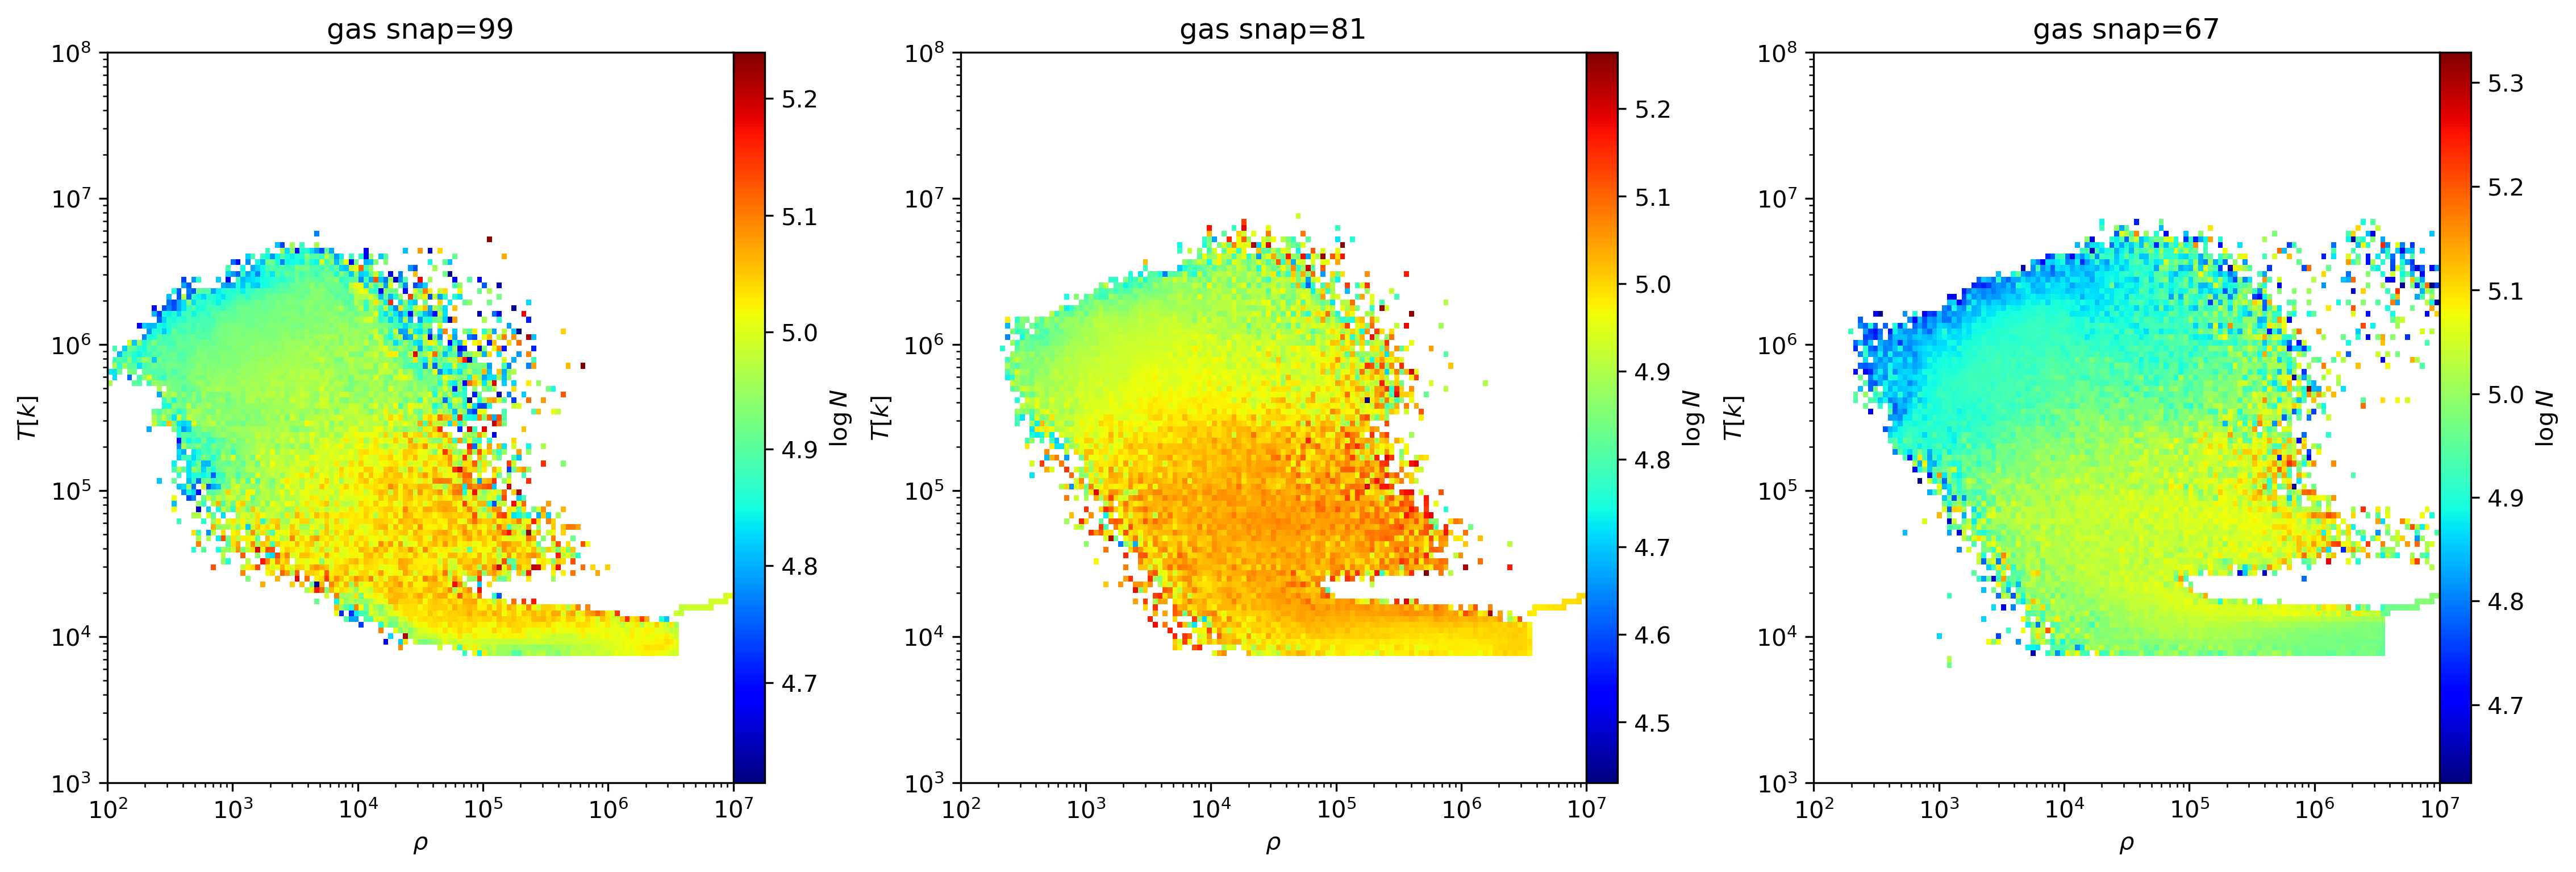

In [31]:
############## Data ##############

snap_number=99 
subfind_number_z0= 517271
box_length= 100
####### List of snap vs z vs aex ########

data = np.load(base_out+"snap_vs_z.npz")
snap_selected = data['snaparr']
z_selected = data['zselected']
aexp_selected = data['aexselected']

######## Track ########

snap_lista= []
z_wanted = np.linspace(zmin,zmax, nz)    
z_wanted = list(z_wanted)

for z in z_wanted:
    idx = find_nearest(z_selected, z)
    snap_lista.append(int(snap_selected[idx]))

snap_lista = list(OrderedDict.fromkeys(snap_lista))
z_wanted = list(np.around(np.array(z_wanted),2))

###########Track ids of subfind_number_z0 for z_wanted ########

fields = ['SubhaloMass','SubfindID','SnapNum']
tree = il.sublink.loadTree(basePath_tng50, 99, subfind_number_z0, fields=fields, onlyMPB=True)
SnapTree = tree['SnapNum']
SubfindIDTree = tree['SubfindID']
mass_msun = tree['SubhaloMass'] * 1e10 / 0.6774

a = SnapTree
b = set(snap_lista)
c =[i for i, item in enumerate(a) if item in b]

subfind_number = SubfindIDTree[c] # The target galaxy from subfind_number_z0
mass_msun = mass_msun[c]


############ FoF and Subfind ###########
fig, axs = plt.subplots(1, 3, constrained_layout=True, dpi=300,figsize=(15,5))

for m, snap_number in enumerate(snap_lista):
    print(f'Processing snapshot {snap_number}...')

    Header = il.groupcat.loadHeader(basePath_tng50, snap_number)
    redsh = Header['Redshift'][()]
    aexp = Header['Time'][()]
    hh = Header['HubbleParam'][()]
    Omega0 = Header['Omega0'][()]
    OmegaLambda = Header['OmegaLambda'][()]
    cosmo = FlatLambdaCDM(H0=hh * 100, Om0=Omega0)
    Hubb = cosmo.H(redsh).to(u.km / u.kpc / u.s).value
    adot = Hubb * aexp
    rho_crit = cosmo.critical_density(redsh).to(u.Msun / u.kpc**3).value

    # --- Group and subhalo data ---
    subhalo = il.groupcat.loadSingle(basePath_tng50, snap_number, subhaloID=subfind_number[m])
    SubhaloPos = np.array(subhalo['SubhaloPos']) / hh
    SubhaloGrNr = subhalo['SubhaloGrNr']
    SubhaloMass = subhalo['SubhaloMass'] * 1e10 / hh

    halo = il.groupcat.loadSingle(basePath_tng50, snap_number, haloID=SubhaloGrNr)
    Group_R_Crit200 = halo['Group_R_Crit200'] * aexp
    Group_M_Crit200 = halo['Group_M_Crit200'] * 1e10 / hh
    GroupPos = halo['GroupPos'] / hh
    GroupVel = halo['GroupVel']

    # --- Physical coordinates and velocities of the group ---
    cmx, cmy, cmz = (GroupPos * aexp)
    vcmx, vcmy, vcmz = (GroupVel * aexp**-1 + GroupPos * adot / hh)
    center = np.array([cmx, cmy, cmz])
    vcenter = np.array([vcmx, vcmy, vcmz])

    ################## Load particle data #################
    dm = snap_phy_subhalo(basePath_tng50, snap_number, subfind_number[m], 1, aexp, adot, hh)
    gas = snap_phy_subhalo(basePath_tng50, snap_number, subfind_number[m], 0, aexp, adot, hh, ['Masses','GFM_Metallicity','InternalEnergy','ElectronAbundance','Density',])
    star = snap_phy_subhalo(basePath_tng50, snap_number, subfind_number[m], 4, aexp, adot, hh, ['Masses', 'Potential'])

    # Dark Matter
    xdm, ydm, zdm = dm['pos'].T
    vxdm, vydm, vzdm = dm['vel'].T
    nDM = len(xdm)
    mDM = np.ones(nDM) * mass_DM_particle * 1e10

    # Stars
    xstar, ystar, zstar = star['pos'].T
    vxstar, vystar, vzstar = star['vel'].T
    ms = star['mass']
    ebin_s = star['pot']

    # Gas
    xgas, ygas, zgas = gas['pos'].T
    vxgas, vygas, vzgas = gas['vel'].T
    mg = gas['mass']
    Z = gas['GFM_Metallicity'] 
    Eint = gas['InternalEnergy'] 
    xe = gas['ElectronAbundance'] 
    Density = gas['Density'] 
    Temp = compute_gas_temperature(Eint,xe)
    

    ######## Recalculate the center of mass ########
    flag_cm = 1
    if flag_cm > 0:
        pos_star = star['pos']
        vel_star = star['vel']
        xcm, ycm, zcm, vxcm, vycm, vzcm = shrinking_sphere(pos_star, vel_star, ms)
    else:
        xcm, ycm, zcm, vxcm, vycm, vzcm = cmx, cmy, cmz, vcmx, vcmy, vcmz

    center = np.array([xcm, ycm, zcm])
    vcenter = np.array([vxcm, vycm, vzcm])

    ################ Relative coordinates #################
    # Stars
    pos_star_rel = star['pos'] - center
    vel_star_rel = star['vel'] - vcenter
    rpristar = np.linalg.norm(pos_star_rel, axis=1)
    order = np.argsort(rpristar)
    rpristar_ord = rpristar[order]
    mstar_ord = ms[order]
    ns = len(mstar_ord)

    # Gas
    pos_gas_rel = gas['pos'] - center
    vel_gas_rel = gas['vel'] - vcenter
    rprigas = np.linalg.norm(pos_gas_rel, axis=1)
    order = np.argsort(rprigas)
    rprigas_ord = rprigas[order]
    mgas_ord = mg[order]
    ng = len(mgas_ord)

    # DM
    pos_dm_rel = dm['pos'] - center
    vel_dm_rel = dm['vel'] - vcenter
    rpridark = np.linalg.norm(pos_dm_rel, axis=1)
    order = np.argsort(rpridark)
    rpridark_ord = rpridark[order]
    mdark_ord = mDM[order]
    nDM = len(mdark_ord)
        
    
    ######### Plot Gas relations #########
    mask = rprigas < Group_R_Crit200
    rprigas = rprigas[mask]
    
    mass = mg[mask].reshape(-1, 1)    
    Z = Z[mask].reshape(-1, 1)    
    Temp = Temp[mask].reshape(-1, 1)    
    Den = Density[mask].reshape(-1, 1)    

    Den_bins = np.logspace(np.log10(1e2), np.log10(1e7), num=128)
    Temp_bins = np.logspace(np.log10(1e3), np.log10(1e8), num=128)
    XDen, DenGrid = np.meshgrid(Den_bins, Den_bins)
    XTemp, TempGrid = np.meshgrid(Den_bins, Temp_bins)

    X,Y=XDen,TempGrid    
       
    ax = axs[m]
    ###################### normal median ############
    hist = np.histogram2d(Den.squeeze(),Temp.squeeze() ,weights=np.ones(len(mass)), bins=(Den_bins, Temp_bins))
    M_hist = np.histogram2d(Den.squeeze(),Temp.squeeze() ,weights=mass.squeeze(), bins=(Den_bins, Temp_bins))

    
    mean_dist = M_hist[0] / hist[0]    
    

    img = np.log10(mean_dist.T)  
    plot = ax.pcolormesh(X,Y,img, cmap='jet', rasterized=True)
    cax = ax.inset_axes([1, 0.0, 0.05, 1], transform=ax.transAxes)
    cbar=fig.colorbar(plot, ax=ax, cax=cax)
    cbar.set_label('$\log$ counts particles')
    
    fig.colorbar(plot, ax=ax, cax=cax, label="$\log N$")
    # Plot legends
    ax.set_title('gas snap='+ str(snap_number))
    ax.set_ylabel('$T[k]$')     
    ax.set_xlabel(r'$\rho$')
    ax.set_xscale('log')
    ax.set_yscale('log')
